# Kalman Filter Q Sweep Analysis

Analyzes `q_{05,10,20}_r_measurement_45_{extend,retract}_100ms.csv` — the same R-measurement
runs as before, but with three different `sigma_v_sq` values (0.5, 1.0, 2.0) at fixed PWM=45.

Goal: quantify how the post-fit residual (`position_reading - position_estimate`) and velocity
estimate respond as Q increases, to find the right direction and a stopping point for tuning.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 4)

DATA_DIR = './'

Q_FILES = {
    'q5_extend':  'q_05_r_measurement_45_extend_100ms.csv',
    'q5_retract': 'q_05_r_measurement_45_retract_100ms.csv',
    'q10_extend':  'q_10_r_measurement_45_extend_100ms.csv',
    'q10_retract': 'q_10_r_measurement_45_retract_100ms.csv',
    'q20_extend':  'q_20_r_measurement_45_extend_100ms.csv',
    'q20_retract': 'q_20_r_measurement_45_retract_100ms.csv',
}
Q_VALUE_OF = {
    'q5_extend': 5.0, 'q5_retract': 5.0,
    'q10_extend': 10.0, 'q10_retract': 10.0,
    'q20_extend': 20.0, 'q20_retract': 20.0,
}

def load_q(fname):
    # Files are UTF-16 (BOM) encoded, comma-separated, with spaces after commas in the header.
    df = pd.read_csv(DATA_DIR + fname, encoding='utf-16')
    df.columns = [c.strip() for c in df.columns]
    df['residual'] = df['position_reading'] - df['position_estimate']
    df['raw_velocity'] = df['position_reading'].diff() / df['delta_t']
    return df

q_data = {name: load_q(f) for name, f in Q_FILES.items()}
{name: len(df) for name, df in q_data.items()}

{'q5_extend': 344,
 'q5_retract': 359,
 'q10_extend': 362,
 'q10_retract': 571,
 'q20_extend': 701,
 'q20_retract': 384}

## 1. Residual and velocity summary per Q value

In [18]:
def lag_autocorr(x, lag=1):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    return np.sum(x[:-lag] * x[lag:]) / np.sum(x**2)

q_rows = []
for name, df in q_data.items():
    r = df['residual'].values
    q_rows.append({
        'run': name,
        'Q (sigma_v_sq)': Q_VALUE_OF[name],
        'direction': 'extend' if 'extend' in name else 'retract',
        'n': len(df),
        'resid_std': r.std(),
        'resid_ac1': lag_autocorr(r, 1),
        'vel_est_std': df['velocity_estimate'].std(),
        'raw_vel_std': df['raw_velocity'].std(),
    })
q_summary = pd.DataFrame(q_rows).set_index('run')
q_summary.round(4)

,Q (sigma_v_sq),direction,n,resid_std,resid_ac1,vel_est_std,raw_vel_std
run,,,,,,,
q5_extend,5.0,extend,344,0.7169,0.9333,16.6605,16.8046
q5_retract,5.0,retract,359,0.6024,0.9302,16.9388,16.7263
q10_extend,10.0,extend,362,0.5381,0.9051,16.5815,16.6803
q10_retract,10.0,retract,571,0.3645,0.8978,15.0768,14.8483
q20_extend,20.0,extend,701,0.3012,0.8674,13.8283,13.8203
q20_retract,20.0,retract,384,0.3441,0.8126,16.7189,16.5446


**Reading this table:**
- `resid_std` — how far the raw reading typically sits from the filter's estimate. Should shrink as
  Q increases (filter trusts measurements more, tracks true position more tightly).
- `resid_ac1` — lag-1 autocorrelation of the residual. Should move toward 0 as Q increases
  (residual becoming less structured / more like white noise) if Q was originally too small.
- `vel_est_std` vs `raw_vel_std` — as long as these stay close, the filter isn't yet amplifying
  sensor noise into the velocity estimate. If `vel_est_std` starts clearly exceeding `raw_vel_std`
  at some Q, that marks the point where you've gone too far.

## 2. Trend plots: resid_std, resid_ac1, and velocity std vs Q

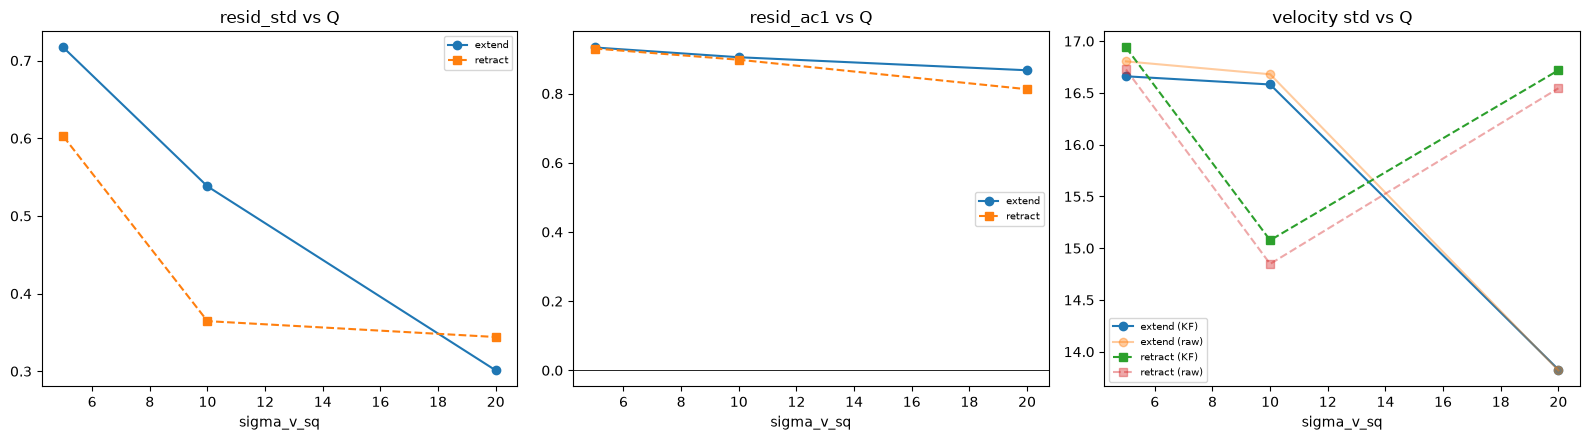

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for direction, marker in zip(['extend', 'retract'], ['o-', 's--']):
    sub = q_summary[q_summary['direction'] == direction].sort_values('Q (sigma_v_sq)')
    axes[0].plot(sub['Q (sigma_v_sq)'], sub['resid_std'], marker, label=direction)
    axes[1].plot(sub['Q (sigma_v_sq)'], sub['resid_ac1'], marker, label=direction)
    axes[2].plot(sub['Q (sigma_v_sq)'], sub['vel_est_std'], marker, label=f'{direction} (KF)')
    axes[2].plot(sub['Q (sigma_v_sq)'], sub['raw_vel_std'], marker, alpha=0.4, label=f'{direction} (raw)')

axes[0].set_title('resid_std vs Q'); axes[0].set_xlabel('sigma_v_sq')
axes[1].set_title('resid_ac1 vs Q'); axes[1].set_xlabel('sigma_v_sq'); axes[1].axhline(0, color='k', lw=0.6)
axes[2].set_title('velocity std vs Q'); axes[2].set_xlabel('sigma_v_sq')
for ax in axes:
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 3. Position and velocity traces per run

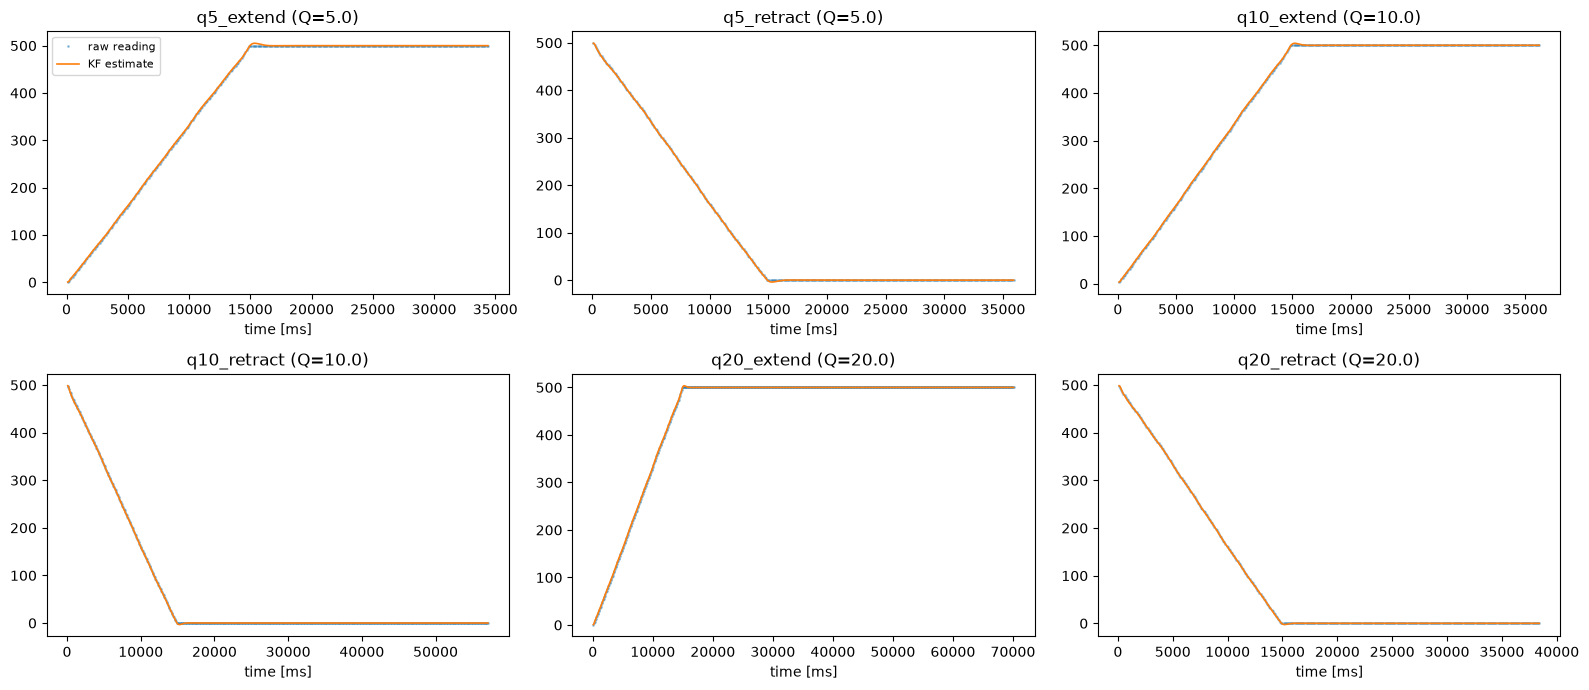

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, (name, df) in zip(axes.flat, q_data.items()):
    ax.plot(df['time'], df['position_reading'], '.', ms=2, alpha=0.4, label='raw reading')
    ax.plot(df['time'], df['position_estimate'], '-', linewidth=1.2, label='KF estimate')
    ax.set_title(f"{name} (Q={Q_VALUE_OF[name]})")
    ax.set_xlabel('time [ms]')
axes.flat[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

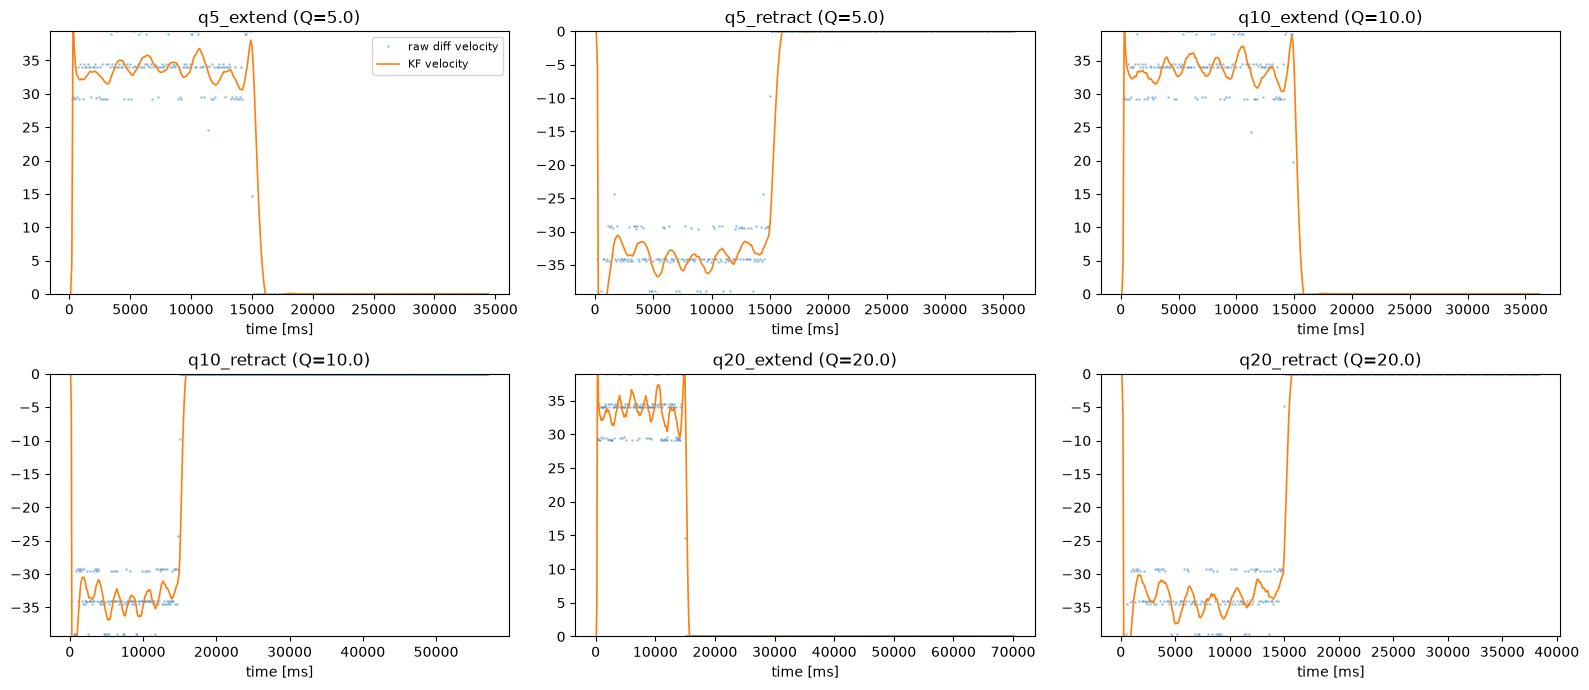

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, (name, df) in zip(axes.flat, q_data.items()):
    ax.plot(df['time'], df['raw_velocity'], '.', ms=2, alpha=0.3, label='raw diff velocity')
    ax.plot(df['time'], df['velocity_estimate'], '-', linewidth=1.2, label='KF velocity')
    ax.set_title(f"{name} (Q={Q_VALUE_OF[name]})")
    ax.set_xlabel('time [ms]')
    ax.set_ylim(np.nanpercentile(df['raw_velocity'].dropna(), [1, 99]))
axes.flat[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Automatic verdict

In [22]:
q_sorted = sorted(set(Q_VALUE_OF.values()))
trend_resid_std = q_summary.groupby('Q (sigma_v_sq)')['resid_std'].mean().reindex(q_sorted)
trend_ac1 = q_summary.groupby('Q (sigma_v_sq)')['resid_ac1'].mean().reindex(q_sorted)
trend_vel_ratio = (q_summary.groupby('Q (sigma_v_sq)')['vel_est_std'].mean()
                   / q_summary.groupby('Q (sigma_v_sq)')['raw_vel_std'].mean()).reindex(q_sorted)

print("Mean resid_std by Q:\n", trend_resid_std.round(4), "\n")
print("Mean resid_ac1 by Q:\n", trend_ac1.round(4), "\n")
print("Mean vel_est_std / raw_vel_std by Q:\n", trend_vel_ratio.round(4), "\n")

resid_std_decreasing = trend_resid_std.is_monotonic_decreasing
ac1_decreasing = trend_ac1.is_monotonic_decreasing
vel_ratio_blowing_up = trend_vel_ratio.iloc[-1] > 1.3  # KF noticeably noisier than raw signal

print("VERDICT:")
if resid_std_decreasing and ac1_decreasing and not vel_ratio_blowing_up:
    print(f"resid_std and resid_ac1 both fall monotonically from Q={q_sorted[0]} to Q={q_sorted[-1]},")
    print("and vel_est_std has not yet exceeded raw_vel_std by a meaningful margin.")
    print("-> Still under-tuned. Keep increasing Q (try the next step up, e.g. x2-5 the last value)")
    print("   and re-run this same analysis until resid_ac1 approaches 0 or vel_est_std starts to")
    print("   clearly exceed raw_vel_std.")
elif vel_ratio_blowing_up:
    print("vel_est_std has grown well past raw_vel_std -> the filter is now amplifying sensor noise.")
    print("-> You've overshot. Back off Q toward the previous, lower value.")
else:
    print("Trend is mixed/non-monotonic -> inspect the table and plots above manually before")
    print("changing Q further.")

Mean resid_std by Q:
 Q (sigma_v_sq)
5.0     0.6597
10.0    0.4513
20.0    0.3226
Name: resid_std, dtype: float64 

Mean resid_ac1 by Q:
 Q (sigma_v_sq)
5.0     0.9317
10.0    0.9014
20.0    0.8400
Name: resid_ac1, dtype: float64 

Mean vel_est_std / raw_vel_std by Q:
 Q (sigma_v_sq)
5.0     1.0020
10.0    1.0041
20.0    1.0060
dtype: float64 

VERDICT:
resid_std and resid_ac1 both fall monotonically from Q=5.0 to Q=20.0,
and vel_est_std has not yet exceeded raw_vel_std by a meaningful margin.
-> Still under-tuned. Keep increasing Q (try the next step up, e.g. x2-5 the last value)
   and re-run this same analysis until resid_ac1 approaches 0 or vel_est_std starts to
   clearly exceed raw_vel_std.
